In [1]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
data_path = Path("../input/datasets/loubl00m/drones")
train_path = data_path / "train"
val_path = data_path / "valid"
input_shape = (640, 640,)

In [12]:
img_paths = sorted(list((train_path / "images").iterdir()))[:6]
label_paths = [train_path / "labels" / img.with_suffix(".txt").name for img in img_paths]

In [17]:
list(zip(img_paths, label_paths))

[(PosixPath('../input/datasets/loubl00m/drones/train/images/1006_JPEG_jpg.rf.37f1b92070f9f47bc8538b9f44f7086c.jpg'),
  PosixPath('../input/datasets/loubl00m/drones/train/labels/1006_JPEG_jpg.rf.37f1b92070f9f47bc8538b9f44f7086c.txt')),
 (PosixPath('../input/datasets/loubl00m/drones/train/images/1010_JPEG_jpg.rf.b0b7b5556c96b5b0cc3d16ba8d8f11e6.jpg'),
  PosixPath('../input/datasets/loubl00m/drones/train/labels/1010_JPEG_jpg.rf.b0b7b5556c96b5b0cc3d16ba8d8f11e6.txt')),
 (PosixPath('../input/datasets/loubl00m/drones/train/images/109_JPEG_jpg.rf.428dde29c64a99a8cd54c1927d0dd6ac.jpg'),
  PosixPath('../input/datasets/loubl00m/drones/train/labels/109_JPEG_jpg.rf.428dde29c64a99a8cd54c1927d0dd6ac.txt')),
 (PosixPath('../input/datasets/loubl00m/drones/train/images/114_JPEG_jpg.rf.b4855da22aff1f72254488b64a1f7bf3.jpg'),
  PosixPath('../input/datasets/loubl00m/drones/train/labels/114_JPEG_jpg.rf.b4855da22aff1f72254488b64a1f7bf3.txt')),
 (PosixPath('../input/datasets/loubl00m/drones/train/images/116_

In [14]:
def read_images(path):
    images = [cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB) for img_path in path]
    return np.stack(images)
    
def read_labels(path):
    labels = []
    for file in label_paths:
        with open(file, 'r') as f:
            labels.append(list(map(float, f.read().split())))
    return labels
    
train_images = read_images(img_paths)
train_labels = read_labels(train_path)

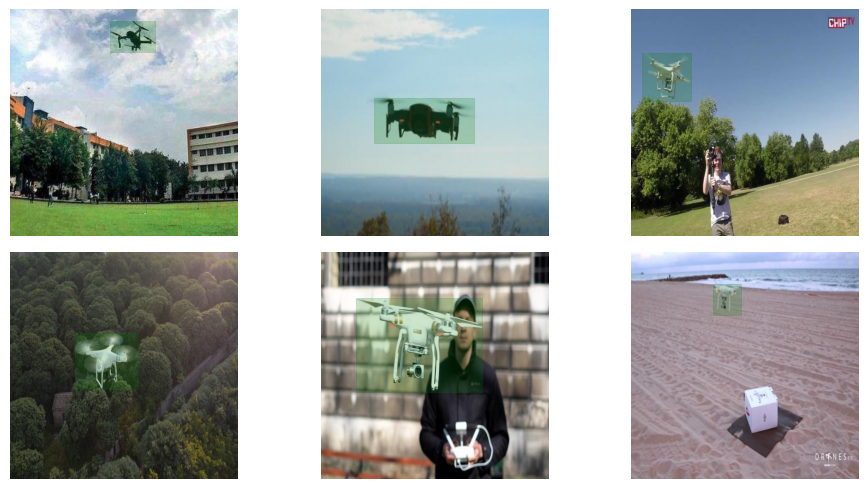

In [21]:
def show_label(image, label, ax, img_shape = (640, 640, 3)):
    h, w, _ = img_shape
    ax.set_axis_off()
    ax.imshow(image)
    for i in range(0, len(label), 5):
        _, bx, by, bw, bh = label[i: i + 5]
        bx1 = (bx - bw / 2) * w
        by1 = (by - bh / 2) * h
        
        rect = patches.Rectangle(
            xy=(bx1, by1),       
            width=bw * w,          
            height=bh * h,       
            linewidth=0.5,
            edgecolor='green',
            facecolor='green',
            alpha=0.2,
            label='Drone'
        )
        ax.add_patch(rect)

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
for ax, image, label in zip(axes.flatten(), train_images, train_labels):
    show_label(image, label, ax)

plt.tight_layout()
plt.show()